# Ch9. 베이지안 기법

: 매개 변수에 대한 사전적 가정을 하는 머신러닝의 하위 집합

[9.1] 베이지안 프레임워크
- So far, 오직 데이터에만 의존 ~ '빈도주의': 한 데이터셋이 주어지면 고유한 최적 매개 변수 집합을 추출 -> 최상의 모델로 간주
- 베이지안 주의자: 데이터셋을 "현실의 스냅샷"으로 간주 -> "매개 변수는 무작위적이다!" ~ 매개 변수의 전체 분포를 파악하려 함
- 베이지안 분석 기본 개념: 조건부 확률
$\\$For 2개의 무작위적 집합 A, B: 
- $P[A|B]=\frac{P[A \cap B]}{P[B]}$
- $P[A \cap B] = P[A]P[B|A]$
- n개의 서로소인 사건들 $A_i,\ i=1,...,n$에 대해 $\sum^n_{i=1}P(A_i)=1$일 때, 어떤 사건 B에 대한 전환률 법칙: 
$\\P(B)=sum^n_{i=1}P(B\cap A_i)=\sum^n_{i=1}P(B|A_i)P(A_i)$
$\\ \therefore P(A_i|B)=\frac{P(A_i)P(B|A_i)}{P(B)}= \frac{P(A_i)P(B|A_i)}{\sum_{i=1}^nP(B|A_i)P(A_i)}$

- 매개변수 $\theta$의 분포: 통계학자가 설정한 사전 분포 + 데이터의 경험적 분포가 혼합된 형태
- $p(\boldsymbol{\theta}| \textbf{y})=\frac{p(\boldsymbol{\theta})p(\textbf{y} |\boldsymbol{\theta})}{p(\textbf{y})} \propto p(\boldsymbol{\theta})p(\textbf{y} |\boldsymbol{\theta})$
- 데이터 $\textbf{y}$를 알고 있을 때 매개 변수 $\boldsymbol{\theta}$의 분포: $\boldsymbol{\theta}$의 분포 X $\boldsymbol{\theta}$을 알고 있을 때의 $\textbf{y}$ 분포
- $p$: 전체 확률 밀도 함수
- 베이지안 분석의 전반적 목적: 사전 분포 $p(\textbf{y})$와 우도함수 $p(\textbf{y} |\boldsymbol{\theta})$를 통해 사후 분포라 불리는 $p(\textbf{y} |\boldsymbol{\theta})$ 구하기
- 사전 분포: 사용자가 사전 분포의 관련성 or 견고함에 대해 확신하는 정도에 따라 정보적/약정보적/비정보적이라 함
$\\ \rarr$ 비정보적 사전 확률: 현실적인 간격에 걸쳐 일정한(균일한) 분포를 설정함
- 분포의 새로운 매개변수들이 $\lambda$로 모임 -> 우도 함수: $p(\textbf{y} |\boldsymbol{\theta}, \boldsymbol{\lambda})=\prod_{i=1}^I f_{\boldsymbol{\lambda}}(y_i; \boldsymbol{\beta})$
$\\ \rarr$ 사후분포: y가 주어졋을 떄 $\theta$와 $\lambda$의 결합 분포를 구해야 함 -> "계층적 모델" by 중첩된 구조

[9.2] 베이지안 샘플링
1. 깁스 샘플링
- 베이즈 정리와 인접해 있는 응용 분야 중 하나: 시뮬레이션
- 밀도 $p=p(x_1,..,x_J)$ ~ 임의의 벡터 $\textbf{X}$의 다변량 분포 시뮬레이션
- $p(X_j=x_j|X_1=x_1,..,X_J=x_J)=p(X_j=x_j|X_{-j}=x_{-j})$ ~ 조건부 확률의 표본 추출할 수 있다고 가정
- j번째 변수 $X_j$의 $m$번째 표본 $x_j^m$ 
- 사전(고정 or 무작위) 표본 $x^0=(x^0_1,...,x^0_J)$에서 시뮬레이션 시작
$\\$(\*) 깁스 알고리즘:
$x_1^{m+1} = p(X_1|X_2=x_2^{m}, \dots ,X_J=x_J^m); \\
x_2^{m+1} =p(X_2|X_1=x_1^{m+1}, X_3=x^{m}_3,.., X_J=x_J^m); \\
\dots \\ x_J^{m+1}= p(X_J|X_1=x_1^{m+1}, X_2=x_2^{m+1}, \dots, X_{J-1}=x_{J-1}^{m+1})$
- 각각의 새로운 반복은 그 이전 반복에만 의존함 -> 마르코프 체인과 관련

2. 메트로폴리스-헤이스팅스 샘플링
- 전체 분포 복잡 & 조건부 법칙 결정하여 표본 추출하기: 어려운 경우 있음 -> 무작위 변수의 시뮬레이션 위해 거부(rejection) 방법에 의존하는 메트로폴리스-헤이스팅스(more general) 방법 사용 가능
- 깁스 알고리즘: MH의 특별한 케이스
$\\$(\*) MH 알고리즘:
- $\textbf{x}$의 초기 값이 샘플링되면($x_0$)시뮬레이션의 각 신규 반복($m$)은 세 단계로 진행됨
1. $p(\textbf{x}|\textbf{x}_m)$에서 후보 값 $\textbf{x}'_{m+1}$ 생성
2. 수용 비율 $\alpha=min(\frac{p(\textbf{x}'_{m+1})p(\textbf{x}_m|\textbf{x}'_{m+1})}{p(\textbf{x}_m)p(\textbf{x}'_{m+1}|\textbf{x}_m)})$
3. 확률 $\alpha$로 $\textbf{x}_{m+1}=\textbf{x}'_{m+1}$을 선택하거나 확률 $1-\alpha$로 이전 값($\textbf{x}_{m+1}=\textbf{x}_m$)을 유지
- '번인': 연쇄 작용이 높은 확률 영역으로 수렴하는 시간을 확보하기 위해 첫 번째 시뮬레이션은 종종 폐기됨

[9.3] 베이지안 선형 회귀
- 선형 모델: $y_i=\textbf{x}_i\textbf{b}+\epsilon_i$
- $\epsilon_i$: i.i.d 이며 평균 0, 분산 $\sigma^2$인 정규 분포를 따른다고 통계적으로 가정
- 우도: $p(\boldsymbol{\epsilon}|\textbf{b}, \sigma)=\prod_{i=1}^I\frac{e^{-\frac{\epsilon_i^2}{2\sigma}}}{\sigma\sqrt{2\pi}}=(\sigma\sqrt{2\pi})^{-I}e^{-\sum_{i=1}^I\frac{\epsilon_i^2}{2\sigma^2}}$
- $\boldsymbol{\epsilon}=\textbf{y}-\textbf{Xb}$
- $\\p(\textbf{y},\textbf{X}|\textbf{b}, \sigma) =\prod_{i=1}^I\frac{e^{-\frac{\epsilon_i^2}{2\sigma}}}{\sigma\sqrt{2\pi}}\\
=(\sigma\sqrt{2\pi})^{-I}e^{-\sum_{i=1}^I\frac{\left(y_i-\textbf{x}_i'\textbf{b}\right)^2}{2\sigma^2}}=(\sigma\sqrt{2\pi})^{-I} e^{-\frac{\left(\textbf{y}-\textbf{X}\textbf{b}\right)' \left(\textbf{y}-\textbf{X}\textbf{b}\right)}{2\sigma^2}} \nonumber \\
=\underbrace{(\sigma\sqrt{2\pi})^{-I} e^{-\frac{\left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)' \left(\textbf{y}-\textbf{X}\hat{\textbf{b}}\right)}{2\sigma^2}}}_{\text{depends on } \sigma, \text{ not } \textbf{b}}\times \underbrace{e^{-\frac{(\textbf{b}-\hat{\textbf{b}})'\textbf{X}'\textbf{X}(\textbf{b}-\hat{\textbf{b}})}{2\sigma^2}}}_{\text{ depends on both } \sigma, \text{ and } \textbf{b} }$


-> 위 표현식: 사후 확률의 빈도주의적(데이터 기반) 블록(: 우도)
- 사후 확률에 대한 단순한 표현식 얻으려면 이 우도와 잘 결합할 수 있는 사전 요인을 찾아야 함: 켤레 사전 확률
- 오른쪽 부분에 대한 후보 값: 다변량 가우스 밀도 ~ $p[\textbf{b}|\sigma]=\sigma^{-k}e^{-\frac{(\textbf{b}-\textbf{b}_0)'\boldsymbol{\Lambda}_0(\textbf{b}-\textbf{b}_0)}{2\sigma^2}}$

[9.4] 나이브 베이스 분류기
- 베이즈 정리: 쉽게 분류 문제에 적용 가능
- $P[\textbf{y} | \textbf{x}_1,\dots,\textbf{x}_K] \propto P[\textbf{x}_1,\dots,\textbf{x}_K| \textbf{y}]P[\textbf{y}]$
- if 특성들이 모두 상호 독립적, $P[\textbf{y} | \textbf{x}_1,\dots,\textbf{x}_K] \propto P[\textbf{y}]\prod_{k=1}^K P[\textbf{x}_k| \textbf{y}]$
- $P[x_{i,k}=z|\textbf{y}_i= c]=\frac{e^{-\frac{(z-m_c)^2}{2\sigma_c^2}}}{\sigma_c\sqrt{2\pi}}$
- $\sigma_c$, $m_c$: $y_i$가 $c$와 같다는 조건 하에서의 $x_{i,k}$의 표준오차와 평균 ~ 훈련셋 필터링 + 샘플링 통계로 사용됨
- 실증적 누적 밀도 함수 $F_{x_k}$를 갖는 특성 벡터 $x_k$: $\tilde{\textbf{x}}_k=\Phi^{-1}\left(F_{\textbf{x}_k}(\textbf{x}_k) \right)$
$\\ \rarr$ 병리적이지 않기만 한다면 이 변수는 표준 정규 법칙을 가짐
- 병리적이지 않은 경우: 누적 밀도 함수가 연속적+엄격하게 증가 & 관측치가 개방 구간 (0,1)에 있는 경우
- 사전 확률: 클래스 전체에 걸쳐 균일하거나 샘플 분포와 같다고 가정하는 경우가 많음

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import QuantileTransformer
import import_ipynb
from Ch1 import data_ml, features_short, idx_train, idx_test
training_sample=data_ml[data_ml.index.isin(idx_train)]
testing_sample=data_ml[data_ml.index.isin(idx_test)]
y_c_train=training_sample['R1M_Usd_C'].values
y_c_test=testing_sample['R1M_Usd_C'].values
import pandas as pd

In [3]:
# 데이터 분포를 강제로 표준 정규분포 모양으로 펴줌
quantile=QuantileTransformer(output_distribution='normal')
# if 데이터에 0/1 끝값 포함, 정규분포 변환시 문제 발생 가능
gauss_features_train=quantile.fit_transform(training_sample[features_short]*0.999+0.0001)

gauss_features_test=quantile.fit_transform(testing_sample[features_short]*0.999+0.0001)

# 분류기
fit_NB_gauss=GaussianNB() # 모든 입력 데이터가 정규분포 가정
# 모델 피팅
fit_NB_gauss.fit(gauss_features_train, y_c_train)
# 모델로부터 예측
data_GNB=pd.DataFrame(fit_NB_gauss.predict(gauss_features_test), columns=['proba'])
data_GNB_cond=pd.concat([data_GNB, pd.DataFrame(gauss_features_test,columns=features_short)],axis=1)
df_TRUE=data_GNB_cond.loc[data_GNB_cond['proba']==1, features_short]
df_FALSE=data_GNB_cond.loc[data_GNB_cond['proba']==0, features_short]

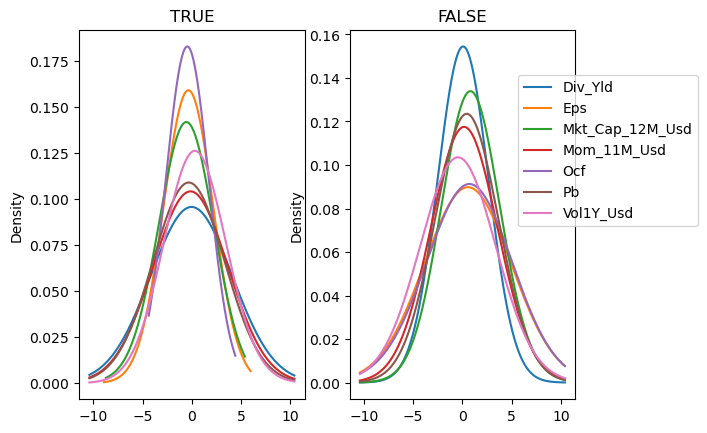

<Figure size 1500x600 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
fig=plt.figure()
ax1=fig.add_subplot(121)
ax2=fig.add_subplot(122)
df_TRUE.plot.kde(bw_method=3, title='TRUE',ax=ax1, legend=False)
df_FALSE.plot.kde(bw_method=3, title='FALSE',ax=ax2,legend=False)
handles, labels= ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.8,0.8))
plt.figure(figsize=(15,6))
plt.show()


[9.5] 베이지안 가법 트리 (어렵 ㅠ)
- 베이지안 가법 회귀 트리(BART): 베이지안적 사고 + 회귀 트리 ~ 앙상블 기법
- M개 모델의 결합: $y=\sum^M_{m=1}\mathcal{T}_m(q_m,\textbf{w}_m, \textbf{x}) + \epsilon$
- $\epsilon$: 분산 $\sigma^2$를 갖는 가우시안 잡은 
- $\mathcal{T}_m=\mathcal{T}_m(q_m,\textbf{w}_m, \textbf{x})$: 구조 $q_m$과 벡터 $\textbf{w}_m$을 갖는 의사결정트리
- $q_m$: 모든 분할(분할에 선택된 변수 및 분할 레벨) 정함
- $\textbf{w}_m$: 최종 노드에서의 잎사귀 값
- 거시적 수준에서 전통적 베이지안 객체 ~ $(q_m, \textbf{w}_m, \sigma^2)|(\textbf{X}, \textbf{Y})$
$\\ \rarr$ 사전 값의 특정 형태 주어지면 MH 및 깁스 샘플러의 결합 하용해 매개 변수 도출함 

[9.5.2] 사전 값
- 트리 모델에서 사전 값의 정의 복잡함
1. 독립성: 모든 매개 변수 간의 독립성, 트리 간의 독립성 ~ BART를 랜덤 포레스트에 가깝게 만듦, 부스트 트리와 멀어짐
$\\ P(\left(q_1,\textbf{w}_1\right),\dots,\left(q_M,\textbf{w}_M\right),\sigma^2)=P(\sigma^2)\prod_{m=1}^MP\left(q_m,\textbf{w}_m\right)$
$\\ P(\left(q_1,\textbf{w}_1\right),\dots,\left(q_M,\textbf{w}_M\right),\sigma^2)=\underbrace{P(\sigma^2)}_{\text{noise term}}\prod_{m=1}^M\underbrace{P\left(\textbf{w}_m|q_m\right)}_{\text{tree weights}}\underbrace{P(q_m)}_{\text{tree struct.}}$

- 세 부분 각각에 대한 가정을 정형화해야 함
$\\$(i) 트리 구조($q_m$): 노드에서의 분할로 트리 정의 ~ 분할 변수와 분할 레벨로 특징지어짐
- 트리의 크기: 깊이 d에서 한 노드가 다음과 같은 확률로 최종 노드가 되지 않도록 매개 변수화함: $\alpha(1+d)^{-\beta},\ \alpha\in(0,1),\ \beta>0$ ~ 상대적으로 얕은 구조를 강제하는 것이 목표
- 분할 변수의 선택: 하나의 특정 특성을 선택할 확률을 정의하는 베르누이(범주형) 분포에 의해 결정됨
$\\$(ii) 트리 구조의 사전 값 결정 후 잎사귀의 최종값 $(\textbf{w}_m|q_m)$ 고정
- 모든 잎사귀의 가중치: 가우시안 분포 $\mathcal{N}(\mu_\mu, \sigma_\mu^2)$ 가정
$\\$(iii) $\sigma^2$: 선형 회귀와 유사한 계산 목적을 위해 베이지안 회귀에서 사용한 것과 유사한 역감마 범칙을 가정

In [8]:
!pip install xbart

  Using cached xbart-0.1.8.tar.gz (212 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Users\82103\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\82103\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\82103\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\82103\AppData\Local\Temp\pip-build-env-21ll4cqu\overlay\Lib\site-packages\setuptools\build_meta.py", line 331, in get_requires_for_build_wheel
          return 

In [11]:
import xbart
fit_bart=xbart.XBART(
    num_trees=20,
    num_sweeps=300, # 추출된 사후 값 개수
    burnin=100, # 번인 샘플 크기
    alpha=0.95,
    beta=2.0
)
fit_bart.fit(training_sample[features_short],training_sample['R1M_Usd'])

XBART(num_trees = 20, num_sweeps = 300, n_min = 1, num_cutpoints = 100, alpha = 0.95, beta = 2.0, tau = 0.05, burnin = 100, mtry = 7, max_depth_num = 250, kap = 16.0, s = 4.0, verbose = False, parallel = False, seed = 0, model_num = 0, no_split_penality = 4.605170185988092, sample_weights_flag = True, num_classes = 1)

In [12]:
import numpy as np
y_test=testing_sample['R1M_Usd'].values
hitratio=np.mean(fit_bart.predict(
    testing_sample[features_short]
)*y_test>0)
print(f'Hit Ratio: {hitratio}')

Hit Ratio: 0.5437984275296263


<Axes: xlabel='Simulation', ylabel='Sigma'>

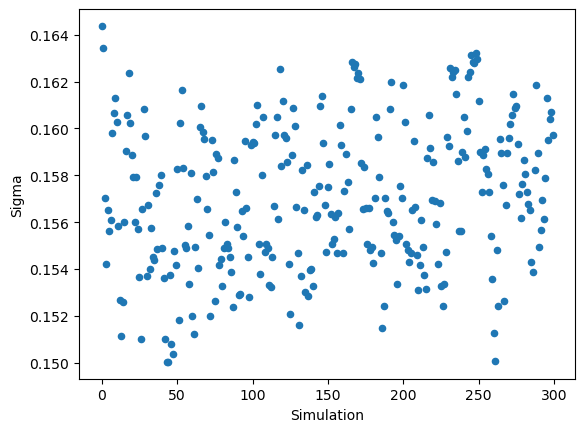

In [13]:
sigma_df=pd.DataFrame(fit_bart.sigma_draws)
sigma_df=sigma_df.mean(axis=1).reset_index()
sigma_df.rename(columns={"index":"Simulation",0:"Sigma"}, inplace=True)
sigma_df.plot.scatter(x='Simulation', y='Sigma')